# Random Forest Models

This notebook documents the Random Forest model family, which became the main model-development focus of the project.

The notebook covers:

1. motivation for Random Forest  
2. comparison of the `daily` and `daily_ohlcv` feature sources  
3. prediction and portfolio results  
4. tuning attempts and their impact  
5. feature importance analysis  
6. final model selection and interpretation  

The objective is to show how the Random Forest models evolved and why the `daily_ohlcv` rolling version was selected as the final model.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
    plot_feature_importance,
)

In [3]:
NOTEBOOK_NAME = "notebook05"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook05


In [4]:
# def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> None:
#     path = TABLES_DIR / filename
#     df.to_csv(path, index=index)
#     print(f"Saved table -> {path}")


# def fig_path(filename: str) -> str:
#     return str(FIGURES_DIR / filename)

def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> pd.DataFrame:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")
    return df


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Why Random Forest?

Random Forest became a major focus because:

- it can model nonlinear interactions
- it is less fragile than many high-capacity alternatives
- it works naturally with tabular engineered features
- it provides interpretable average feature importance

The later model-development process showed that Random Forest generalized more reliably than the more aggressive boosted and neural alternatives.

In [5]:
rf_dirs = {
    "RF daily": PROJECT_ROOT / "experiments" / "results" / "exp04_random_forest_rolling_daily",
    "RF daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp04_random_forest_rolling_daily_ohlcv",
}

rf_dirs

{'RF daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp04_random_forest_rolling_daily'),
 'RF daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp04_random_forest_rolling_daily_ohlcv')}

In [6]:
for name, rf_dir in rf_dirs.items():
    print(f"\n{name}")
    print("dir:", rf_dir)
    for fn in [
        "prediction_metrics.json",
        "metrics_train.json",
        "metrics_test_2025.json",
        "metrics_train_with_costs.json",
        "metrics_test_2025_with_costs.json",
        "equity_train.csv",
        "equity_test_2025.csv",
        "feature_importance_mean.csv",
        "test_predictions.csv",
    ]:
        print(f"{fn}: {(rf_dir / fn).exists()}")


RF daily
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp04_random_forest_rolling_daily
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True
feature_importance_mean.csv: True
test_predictions.csv: True

RF daily_ohlcv
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp04_random_forest_rolling_daily_ohlcv
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True
feature_importance_mean.csv: True
test_predictions.csv: True


In [7]:
def load_rf_experiment(exp_dir: Path) -> dict:
    with open(exp_dir / "prediction_metrics.json", "r") as f:
        prediction_metrics = json.load(f)

    with open(exp_dir / "metrics_train.json", "r") as f:
        metrics_train = json.load(f)

    with open(exp_dir / "metrics_test_2025.json", "r") as f:
        metrics_test = json.load(f)

    with open(exp_dir / "metrics_train_with_costs.json", "r") as f:
        metrics_train_costs = json.load(f)

    with open(exp_dir / "metrics_test_2025_with_costs.json", "r") as f:
        metrics_test_costs = json.load(f)

    equity_train = pd.read_csv(exp_dir / "equity_train.csv", index_col=0).squeeze("columns")
    equity_test = pd.read_csv(exp_dir / "equity_test_2025.csv", index_col=0).squeeze("columns")

    equity_train.index = pd.to_datetime(equity_train.index)
    equity_test.index = pd.to_datetime(equity_test.index)

    # feat_imp = pd.read_csv(exp_dir / "feature_importance_mean.csv") if (exp_dir / "feature_importance_mean.csv").exists() else None
    feat_imp = pd.read_csv(exp_dir / "feature_importance_mean.csv", index_col=0) if (exp_dir / "feature_importance_mean.csv").exists() else None
    test_pred = pd.read_csv(exp_dir / "test_predictions.csv") if (exp_dir / "test_predictions.csv").exists() else None

    return {
        "prediction_metrics": prediction_metrics,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "metrics_train_costs": metrics_train_costs,
        "metrics_test_costs": metrics_test_costs,
        "equity_train": equity_train,
        "equity_test": equity_test,
        "feature_importance": feat_imp,
        "test_predictions": test_pred,
    }

In [8]:
rf_results = {name: load_rf_experiment(path) for name, path in rf_dirs.items()}
rf_results.keys()

dict_keys(['RF daily', 'RF daily_ohlcv'])

In [9]:
rf_setup = save_table(
    pd.DataFrame(
        {
            "model_variant": ["RF daily", "RF daily_ohlcv"],
            "feature_source": ["daily", "daily_ohlcv"],
            "training_scheme": ["rolling", "rolling"],
            "model_family": ["Random Forest", "Random Forest"],
        }
    ),
    "rf_setup_summary.csv",
    index=False,
)
rf_setup

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05\rf_setup_summary.csv


,model_variant,feature_source,training_scheme,model_family
0,RF daily,daily,rolling,Random Forest
1,RF daily_ohlcv,daily_ohlcv,rolling,Random Forest


## 2. Prediction metrics

The Random Forest models are first evaluated as return prediction models.

These metrics describe:

- numerical return prediction quality
- sign correctness
- ranking quality across stocks within each month

In [10]:
prediction_rows = []

for model_name, res in rf_results.items():
    pm = res["prediction_metrics"]

    prediction_rows.append(
        {
            "model": model_name,
            "split": "train_static_fit",
            "MAE": pm["train_static_fit"]["regression"]["MAE"],
            "RMSE": pm["train_static_fit"]["regression"]["RMSE"],
            "R2": pm["train_static_fit"]["regression"]["R2"],
            "Directional_Accuracy": pm["train_static_fit"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["train_static_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["train_static_fit"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["train_static_fit"]["ranking"]["Months_evaluated"],
        }
    )

    prediction_rows.append(
        {
            "model": model_name,
            "split": "test_2025_rolling_fit",
            "MAE": pm["test_2025_rolling_fit"]["regression"]["MAE"],
            "RMSE": pm["test_2025_rolling_fit"]["regression"]["RMSE"],
            "R2": pm["test_2025_rolling_fit"]["regression"]["R2"],
            "Directional_Accuracy": pm["test_2025_rolling_fit"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["test_2025_rolling_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["test_2025_rolling_fit"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["test_2025_rolling_fit"]["ranking"]["Months_evaluated"],
        }
    )

rf_prediction_comparison = save_table(
    pd.DataFrame(prediction_rows),
    "rf_prediction_metrics_comparison.csv",
    index=False,
)
rf_prediction_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05\rf_prediction_metrics_comparison.csv


,model,split,MAE,RMSE,R2,Directional_Accuracy,SpearmanRankCorr_mean,TopKHitRate_mean,Months_evaluated
0,RF daily,train_static_fit,0.058282,0.079246,0.059175,0.545978,0.075922,0.301376,109
1,RF daily,test_2025_rolling_fit,0.054756,0.073859,0.004201,0.563477,0.051451,0.363636,11
2,RF daily_ohlcv,train_static_fit,0.058103,0.078929,0.063833,0.547041,0.092637,0.298715,109
3,RF daily_ohlcv,test_2025_rolling_fit,0.054680,0.073823,0.005175,0.565430,0.081832,0.373206,11


In [11]:
strategy_rows = []

for model_name, res in rf_results.items():
    strategy_rows.append({"model": model_name, "split": "train_2015_2024", **res["metrics_train"]})
    strategy_rows.append({"model": model_name, "split": "test_2025", **res["metrics_test"]})

rf_strategy_comparison = save_table(
    pd.DataFrame(strategy_rows),
    "rf_strategy_metrics_comparison.csv",
    index=False,
)
rf_strategy_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05\rf_strategy_metrics_comparison.csv


,model,split,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,RF daily,train_2015_2024,5.297140,0.202027,0.203278,-0.260750,1.007473,0.381193,0.350000,0.800000
1,RF daily,test_2025,0.357411,0.357411,0.142758,-0.037387,2.230756,0.334928,0.368421,0.578947
2,RF daily_ohlcv,train_2015_2024,6.103098,0.216592,0.200987,-0.264493,1.077556,0.388073,0.350000,0.750000
3,RF daily_ohlcv,test_2025,0.383442,0.383442,0.145716,-0.045831,2.322132,0.301435,0.315789,0.473684


In [12]:
cost_rows = []

for model_name, res in rf_results.items():
    for split_name, cost_dict in [
        ("train_2015_2024", res["metrics_train_costs"]),
        ("test_2025", res["metrics_test_costs"]),
    ]:
        for cost_name, metrics in cost_dict.items():
            row = {"model": model_name, "split": split_name, "cost_scenario": cost_name}
            row.update(metrics)
            cost_rows.append(row)

rf_cost_comparison = save_table(
    pd.DataFrame(cost_rows),
    "rf_cost_adjusted_comparison.csv",
    index=False,
)
rf_cost_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05\rf_cost_adjusted_comparison.csv


,model,split,cost_scenario,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,RF daily,train_2015_2024,cost_0bps,5.297140,0.202027,0.203278,-0.260750,1.007473,0.381193,0.350000,0.800000
1,RF daily,train_2015_2024,cost_10bps,5.044069,0.197107,0.203281,-0.262334,0.987017,0.381193,0.350000,0.800000
2,RF daily,train_2015_2024,cost_20bps,4.801066,0.192205,0.203286,-0.263916,0.966552,0.381193,0.350000,0.800000
3,RF daily,test_2025,cost_0bps,0.357411,0.357411,0.142758,-0.037387,2.230756,0.334928,0.368421,0.578947
4,RF daily,test_2025,cost_10bps,0.352515,0.352515,0.142911,-0.038371,2.202587,0.334928,0.368421,0.578947
5,RF daily,test_2025,cost_20bps,0.347634,0.347634,0.143067,-0.039354,2.174438,0.334928,0.368421,0.578947
6,RF daily_ohlcv,train_2015_2024,cost_0bps,6.103098,0.216592,0.200987,-0.264493,1.077556,0.388073,0.350000,0.750000
7,RF daily_ohlcv,train_2015_2024,cost_10bps,5.812510,0.211520,0.201025,-0.266061,1.056305,0.388073,0.350000,0.750000
8,RF daily_ohlcv,train_2015_2024,cost_20bps,5.533689,0.206468,0.201066,-0.267627,1.035053,0.388073,0.350000,0.750000
9,RF daily_ohlcv,test_2025,cost_0bps,0.383442,0.383442,0.145716,-0.045831,2.322132,0.301435,0.315789,0.473684


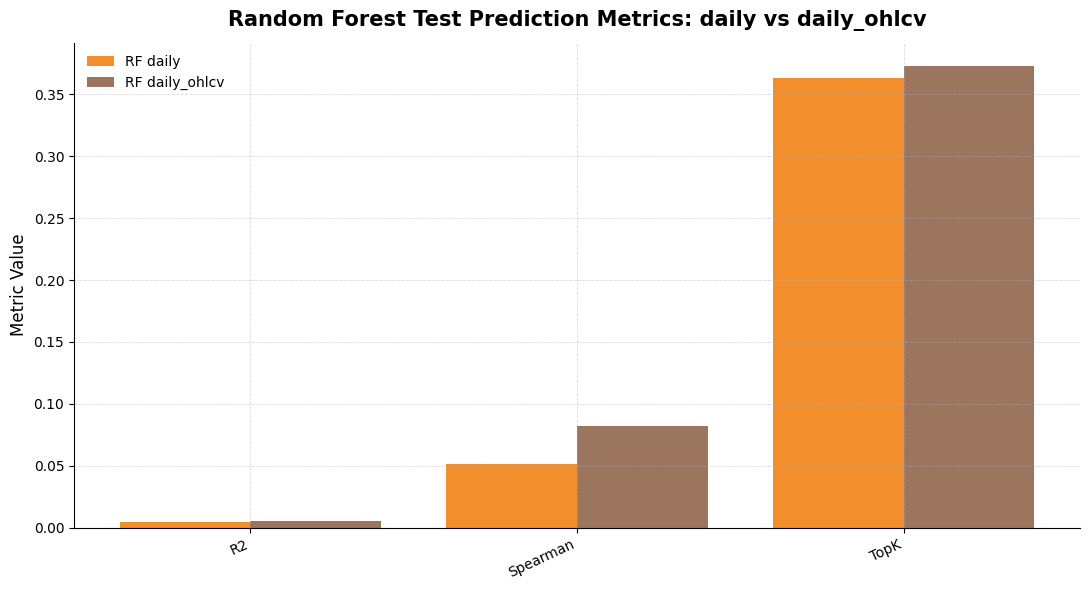

In [13]:
rf_test_pred = rf_prediction_comparison[
    rf_prediction_comparison["split"] == "test_2025_rolling_fit"
].set_index("model")

rf_metric_plot_df = pd.DataFrame(
    {
        "R2": rf_test_pred["R2"],
        "Spearman": rf_test_pred["SpearmanRankCorr_mean"],
        "TopK": rf_test_pred["TopKHitRate_mean"],
    }
).T

plot_grouped_metric_bars(
    metric_df=rf_metric_plot_df,
    title="Random Forest Test Prediction Metrics: daily vs daily_ohlcv",
    ylabel="Metric Value",
    color_map={
        "RF daily": get_model_color("random_forest"),
        "RF daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("rf_test_prediction_metric_comparison.png"),
    show=True,
)

## 3. Equity curves

The cumulative-value paths of the Random Forest portfolios are compared below for both the training and test periods.

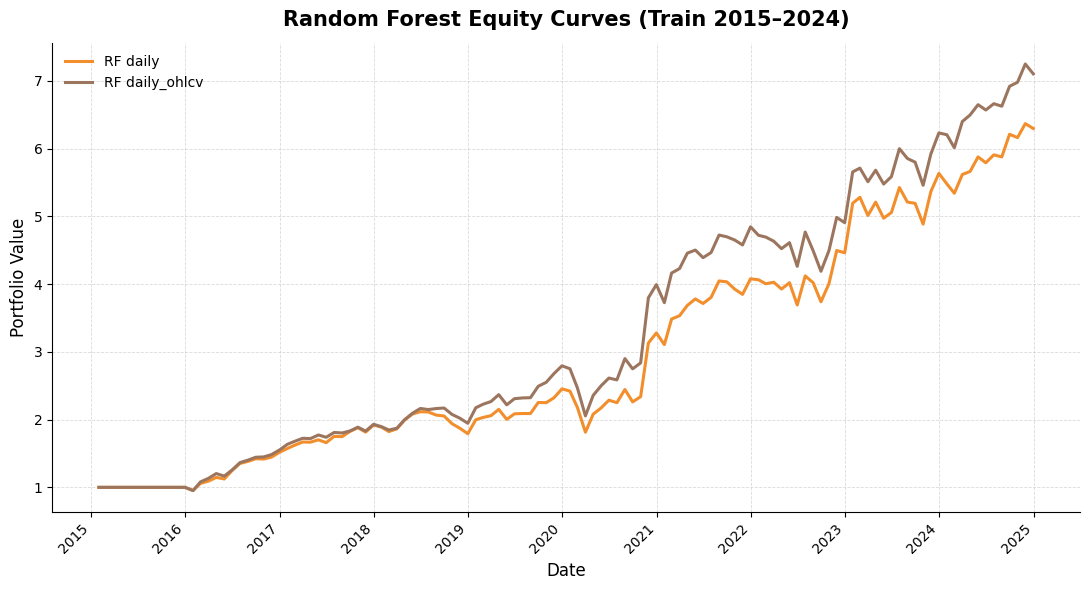

In [14]:
plot_multi_series(
    series_map={
        "RF daily": rf_results["RF daily"]["equity_train"],
        "RF daily_ohlcv": rf_results["RF daily_ohlcv"]["equity_train"],
    },
    title="Random Forest Equity Curves (Train 2015–2024)",
    ylabel="Portfolio Value",
    color_map={
        "RF daily": get_model_color("random_forest"),
        "RF daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("rf_equity_train_comparison.png"),
    show=True,
)

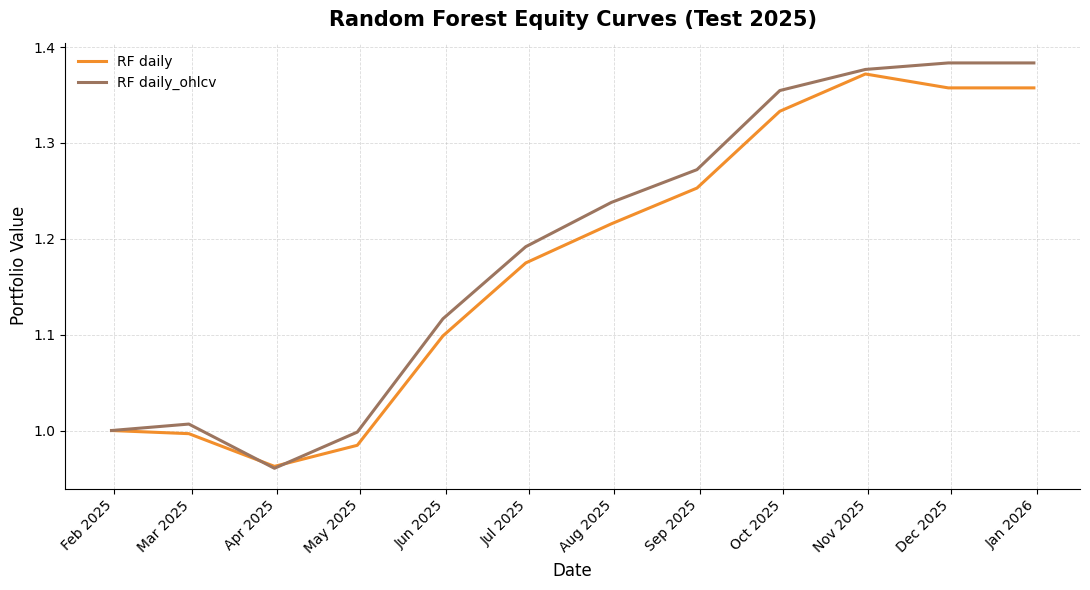

In [15]:
plot_multi_series(
    series_map={
        "RF daily": rf_results["RF daily"]["equity_test"],
        "RF daily_ohlcv": rf_results["RF daily_ohlcv"]["equity_test"],
    },
    title="Random Forest Equity Curves (Test 2025)",
    ylabel="Portfolio Value",
    color_map={
        "RF daily": get_model_color("random_forest"),
        "RF daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("rf_equity_test_comparison.png"),
    show=True,
)

## 4. Drawdowns

Drawdown plots complement the equity curves by showing the magnitude of losses from prior peaks.

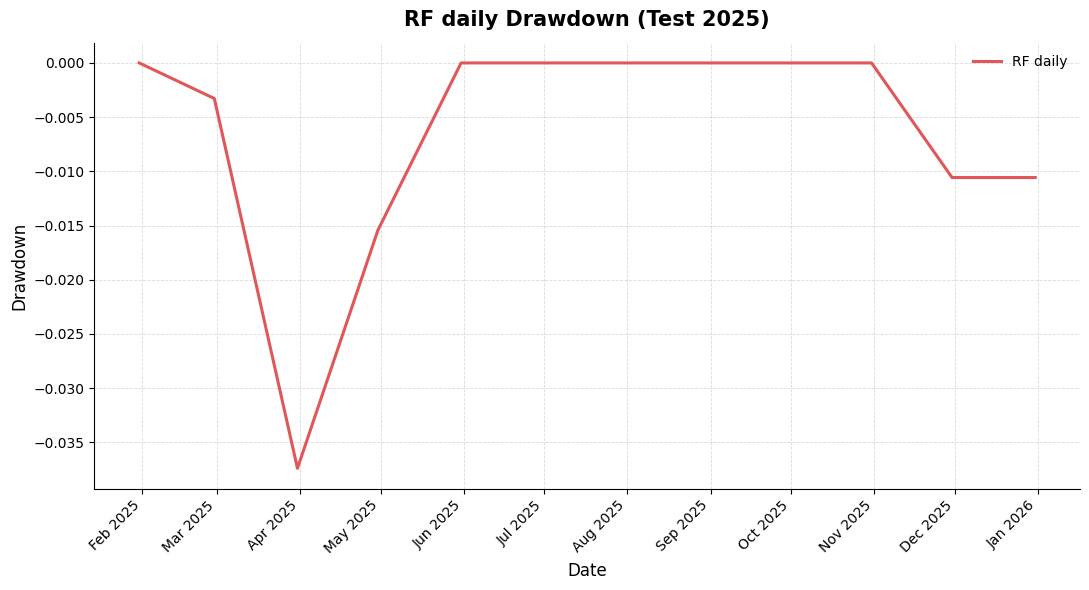

In [16]:
plot_drawdown(
    rf_results["RF daily"]["equity_test"],
    title="RF daily Drawdown (Test 2025)",
    save_path=fig_path("rf_daily_drawdown_test.png"),
    label="RF daily",
    color="#E15759",
    show=True,
)

In [17]:
rf_test_strategy = rf_strategy_comparison[rf_strategy_comparison["split"] == "test_2025"].set_index("model")
rf_test_strategy[["cumulative_return", "annualized_return", "sharpe_ratio", "avg_turnover"]]

,cumulative_return,annualized_return,sharpe_ratio,avg_turnover
model,,,,
RF daily,0.357411,0.357411,2.230756,0.334928
RF daily_ohlcv,0.383442,0.383442,2.322132,0.301435


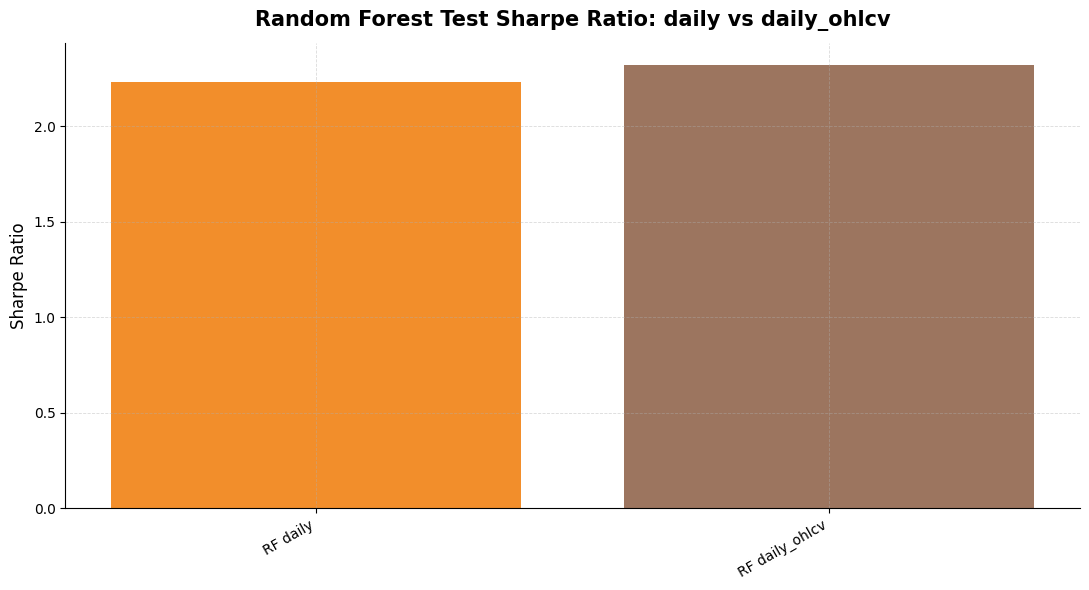

In [18]:
plot_metric_bar(
    rf_test_strategy["sharpe_ratio"],
    title="Random Forest Test Sharpe Ratio: daily vs daily_ohlcv",
    ylabel="Sharpe Ratio",
    color_map={
        "RF daily": get_model_color("random_forest"),
        "RF daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("rf_test_sharpe_comparison.png"),
    show=True,
)

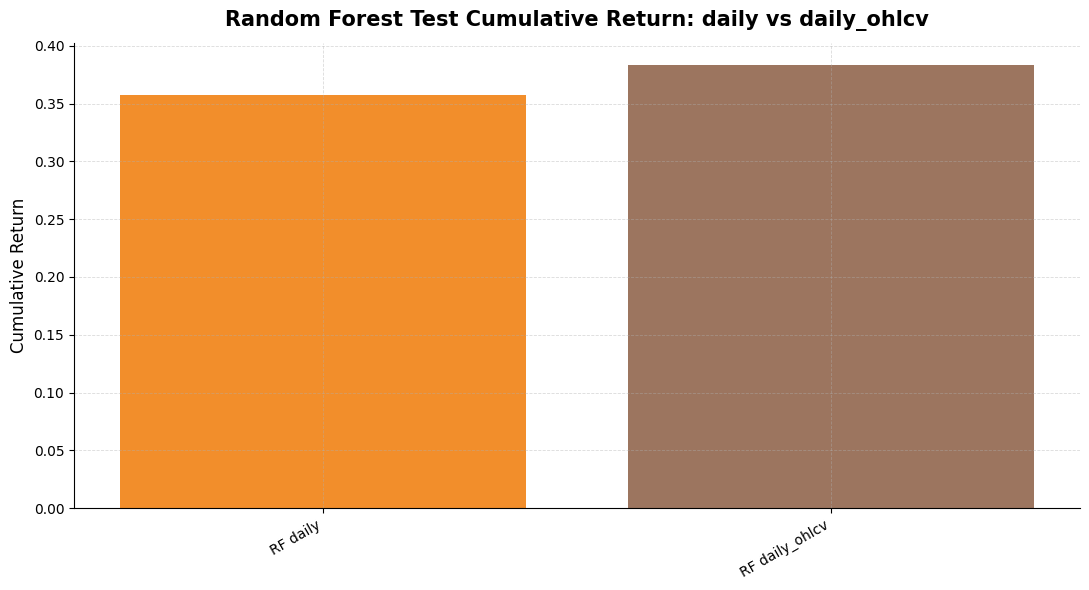

In [19]:
plot_metric_bar(
    rf_test_strategy["cumulative_return"],
    title="Random Forest Test Cumulative Return: daily vs daily_ohlcv",
    ylabel="Cumulative Return",
    color_map={
        "RF daily": get_model_color("random_forest"),
        "RF daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("rf_test_cumulative_return_comparison.png"),
    show=True,
)

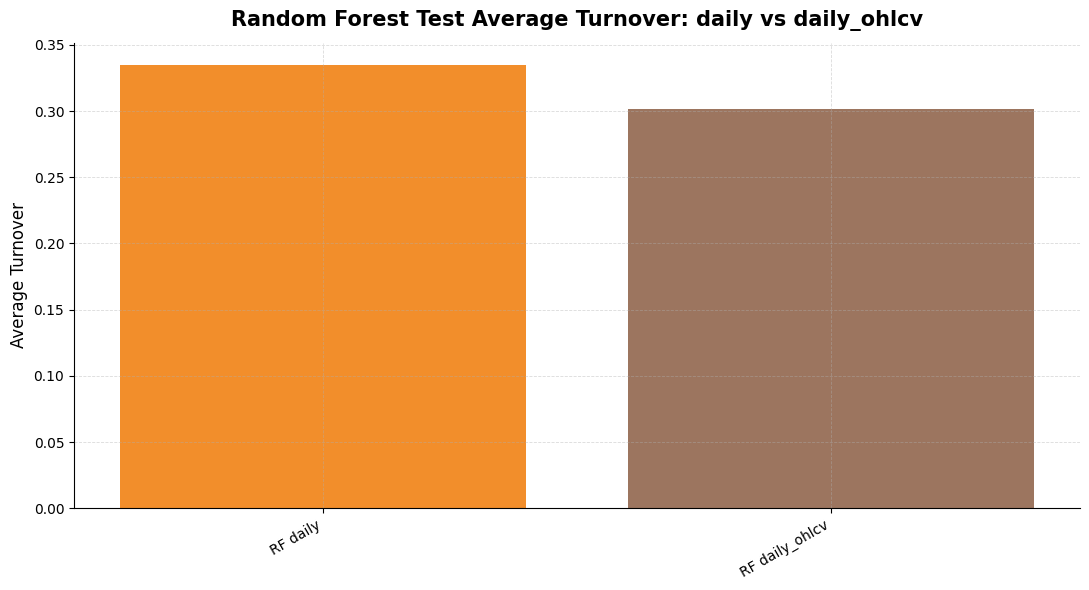

In [20]:
plot_metric_bar(
    rf_test_strategy["avg_turnover"],
    title="Random Forest Test Average Turnover: daily vs daily_ohlcv",
    ylabel="Average Turnover",
    color_map={
        "RF daily": get_model_color("random_forest"),
        "RF daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("rf_test_turnover_comparison.png"),
    show=True,
)

## 5. Feature importance

Average feature importance provides one of the main interpretability advantages of the Random Forest model family.

The plots below show the most important variables in the two RF variants, where available.

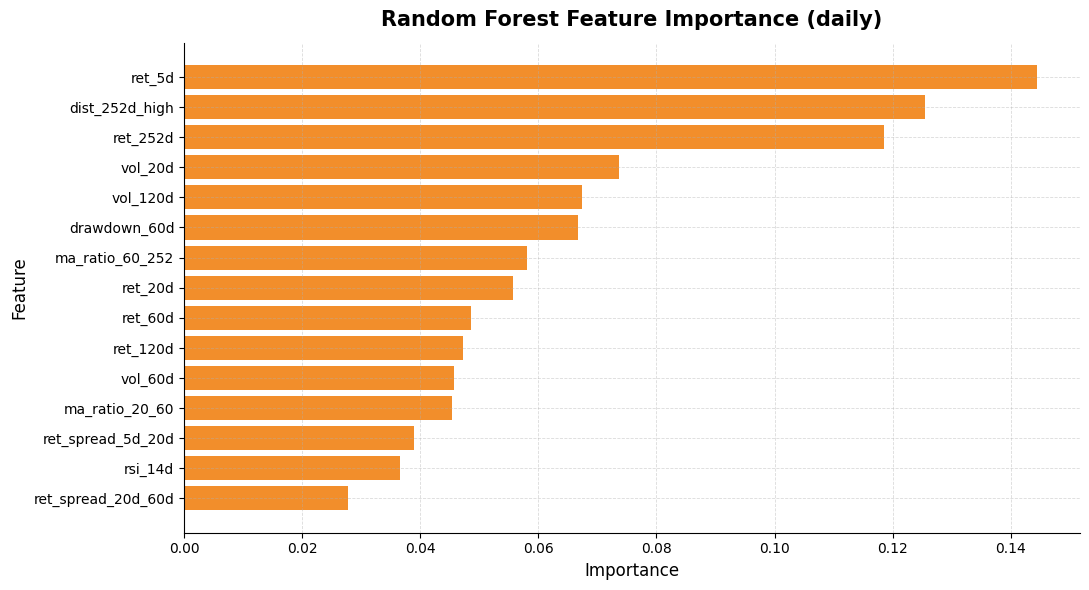

In [21]:
feat_imp_daily = rf_results["RF daily"]["feature_importance"]

if feat_imp_daily is not None:
    imp_series = feat_imp_daily["importance_mean"]
    plot_feature_importance(
        imp_series,
        title="Random Forest Feature Importance (daily)",
        top_n=20,
        save_path=fig_path("rf_daily_feature_importance.png"),
        color=get_model_color("random_forest"),
        show=True,
    )
else:
    print("No feature importance file found for RF daily.")

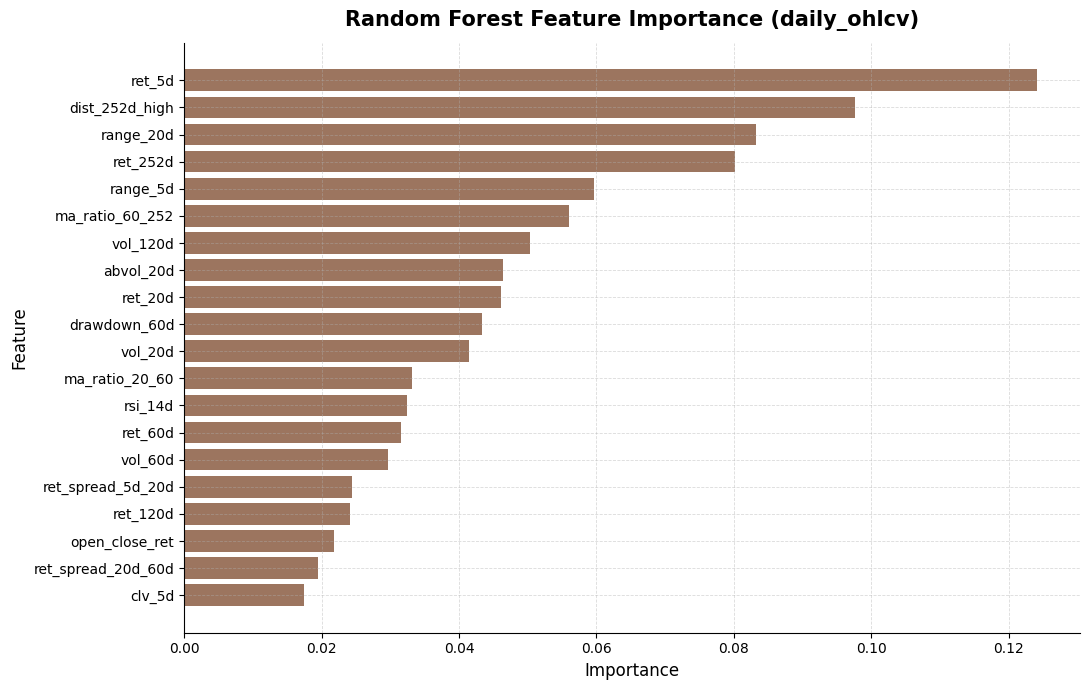

In [22]:
feat_imp_ohlcv = rf_results["RF daily_ohlcv"]["feature_importance"]

if feat_imp_ohlcv is not None:
    imp_series = feat_imp_ohlcv["importance_mean"]
    plot_feature_importance(
        imp_series,
        title="Random Forest Feature Importance (daily_ohlcv)",
        top_n=20,
        save_path=fig_path("rf_daily_ohlcv_feature_importance.png"),
        color="#9C755F",
        show=True,
    )
else:
    print("No feature importance file found for RF daily_ohlcv.")

## 6. Model-development findings

The Random Forest workflow evolved in stages:

1. adjusted-close daily feature model  
2. spread-feature enhancement  
3. rolling retraining  
4. OHLCV feature extension  
5. hyperparameter tuning attempts  

The main empirical finding is that the OHLCV-enhanced rolling Random Forest delivered the strongest overall out-of-sample portfolio performance.

In [23]:
rf_development_summary = save_table(
    pd.DataFrame(
        {
            "stage": [
                "RF daily rolling",
                "RF daily_ohlcv rolling",
                "RF tuning attempts",
            ],
            "main_observation": [
                "Provided a strong tabular benchmark with useful ranking power",
                "Improved ranking quality, Sharpe ratio, cumulative return, and turnover",
                "More regularized tuned variants were informative but did not beat the best untuned daily_ohlcv RF",
            ],
        }
    ),
    "rf_development_summary.csv",
    index=False,
)
rf_development_summary

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05\rf_development_summary.csv


,stage,main_observation
0,RF daily rolling,Provided a strong tabular benchmark with usefu...
1,RF daily_ohlcv rolling,"Improved ranking quality, Sharpe ratio, cumula..."
2,RF tuning attempts,More regularized tuned variants were informati...


## 7. Interpretation

The Random Forest family produced several important results:

- Random Forest generalized more reliably than more aggressive alternatives  
- the OHLCV feature extension improved stock ranking and portfolio construction  
- out-of-sample portfolio performance improved even when exact return-value prediction did not always improve  
- tuning favored more conservative trees, but the best tuned versions did not outperform the strongest untuned `daily_ohlcv` model in final 2025 portfolio evaluation  

These findings explain why the rolling Random Forest with the `daily_ohlcv` feature source became the selected final model.

In [24]:
rf_findings = save_table(
    pd.DataFrame(
        {
            "finding": [
                "Random Forest became the main model-development focus",
                "The OHLCV extension improved out-of-sample ranking and portfolio performance",
                "Feature importance provided useful model interpretability",
                "Tuning favored conservative settings but did not beat the best untuned daily_ohlcv RF",
                "RF daily_ohlcv rolling was selected as the final model",
            ]
        }
    ),
    "rf_key_findings.csv",
    index=False,
)
rf_findings

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook05\rf_key_findings.csv


,finding
0,Random Forest became the main model-developmen...
1,The OHLCV extension improved out-of-sample ran...
2,Feature importance provided useful model inter...
3,Tuning favored conservative settings but did n...
4,RF daily_ohlcv rolling was selected as the fin...


## 8. Final conclusion

The Random Forest model family delivered the strongest overall results in the project.

Among the RF variants, the rolling model using the `daily_ohlcv` feature source achieved the best balance of:

- ranking quality  
- portfolio return  
- Sharpe ratio  
- turnover control  
- robustness after transaction costs  

The next notebook compares this RF family against XGBoost, which offered stronger in-sample fit but weaker out-of-sample generalization.